<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_memory_hold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D10_MEMORY_HOLD — Topological Memory Cell

Status

Working prototype target.

Purpose

This notebook demonstrates memory holding inside a bounded topological field cell.

The previous experiment, D8_BOUNDARY_SPLIT, created isolated address regions.

This experiment writes a signal into one D8 cell, removes the input, and checks whether the cell can hold the state.

Core Idea

D7 creates position.

D8 creates boundaries.

D10 tests memory.

A bounded field cell can behave like a simple memory unit if it can keep activation after the input is removed.

Expected Result

The system should produce:

- D8 boundary map
- selected target memory cell
- write phase
- hold phase
- memory retention table

Diffusion Alphabet Mapping

Symbol:

D10_MEMORY_HOLD

Family:

Memory / Topological State

Meaning:

A bounded diffusion cell holds activation after the input signal is removed.

Repository Name

notebooks/diffusion_memory_hold.ipynb

Experiment Label

Experiment 07 — Topological Memory Hold

Commit Message

Add topological memory hold prototype

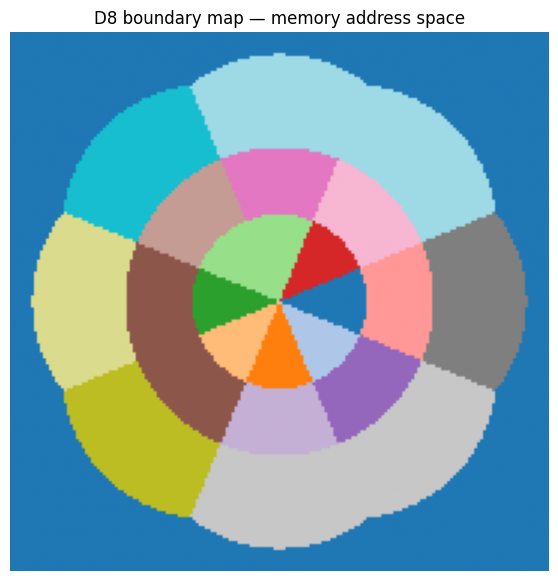

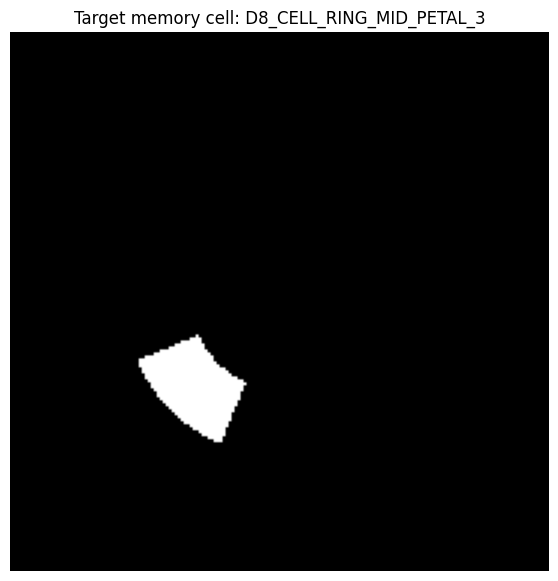

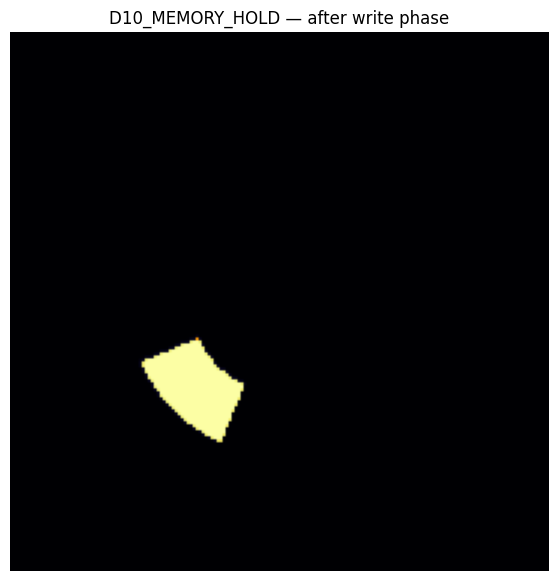

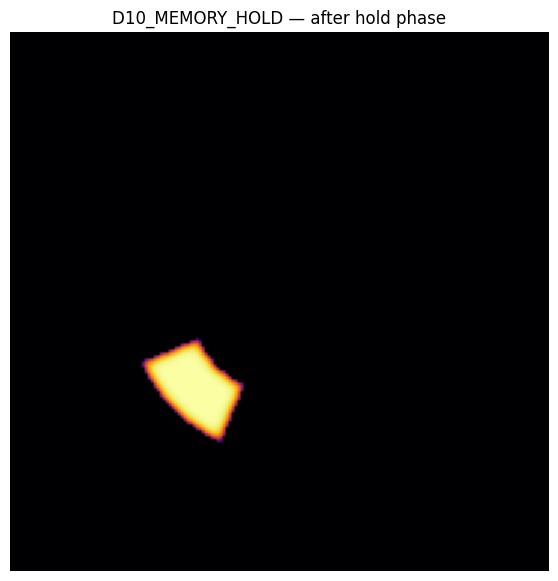

,STATE,PHASE,TARGET_ADDRESS,TARGET_MEAN,TARGET_MAX,OUTSIDE_MEAN,OUTSIDE_MAX
0,D10_MEMORY_HOLD,WRITE_END,D8_CELL_RING_MID_PETAL_3,0.911,1.000,0.000021,0.014
1,D10_MEMORY_HOLD,HOLD_END,D8_CELL_RING_MID_PETAL_3,0.679,0.855,0.000006,0.006


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def laplacian(Z):
    return (
        -4 * Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    )


def generate_radial_morphogen_field(size=180, petals=8, rings=4):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)

    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(Y, X)

    mask = (R <= 1.0).astype(float)

    center = np.exp(-18 * R**2)
    radial_wave = 0.5 + 0.5 * np.cos(2 * np.pi * rings * R)
    angular_wave = 0.5 + 0.5 * np.cos(petals * Theta)
    envelope = np.exp(-1.25 * R)

    Z = (
        0.55 * center
        + 0.45
        * envelope
        * (0.35 + 0.65 * radial_wave)
        * (0.35 + 0.65 * angular_wave)
    )

    Z = Z * mask
    Z = (Z - Z.min()) / (Z.max() - Z.min() + 1e-9)

    return Z, R, Theta, mask


def angular_distance(A, B):
    return np.abs(np.angle(np.exp(1j * (A - B))))


def build_boundary_split(
    Z,
    R,
    Theta,
    mask,
    petals=8,
    ring_centers=(0.20, 0.45, 0.70),
    sigma_r=0.10,
    sigma_theta=0.30,
):
    scores = []

    for ring_index, ring_center in enumerate(ring_centers):
        for petal_index in range(petals):
            theta_center = 2 * np.pi * petal_index / petals

            dr = R - ring_center
            dt = angular_distance(Theta, theta_center)

            radial_score = np.exp(-(dr**2) / (2 * sigma_r**2))
            angular_score = np.exp(-(dt**2) / (2 * sigma_theta**2))

            score = radial_score * angular_score * (0.30 + 0.70 * Z) * mask
            scores.append(score)

    score_stack = np.stack(scores, axis=0)

    label_map = np.argmax(score_stack, axis=0)
    confidence = np.max(score_stack, axis=0)

    label_map = label_map.astype(int)
    label_map[mask == 0] = -1
    label_map[confidence < 0.03] = -1

    boundary = np.zeros_like(label_map, dtype=bool)

    boundary[:, 1:] |= label_map[:, 1:] != label_map[:, :-1]
    boundary[1:, :] |= label_map[1:, :] != label_map[:-1, :]

    boundary[label_map == -1] = False

    return label_map, boundary, confidence


def label_to_address(label, petals=8):
    if label < 0:
        return "D8_OUTSIDE"

    ring_index = label // petals
    petal_index = label % petals

    ring_names = {
        0: "RING_INNER",
        1: "RING_MID",
        2: "RING_OUTER",
    }

    ring_name = ring_names.get(ring_index, f"RING_{ring_index}")

    return f"D8_CELL_{ring_name}_PETAL_{petal_index}"


def run_memory_hold(
    label_map,
    boundary,
    target_label,
    write_steps=25,
    hold_steps=180,
    diffusion=0.08,
    hold_gain=0.11,
    decay=0.016,
    write_strength=0.15,
    wall_damp=0.15,
    outside_damp=0.55,
):
    target_mask = label_map == target_label
    valid_mask = label_map >= 0

    M = np.zeros_like(label_map, dtype=float)

    write_snapshot = None

    for t in range(write_steps + hold_steps):
        writing = t < write_steps

        L = laplacian(M)

        local_hold = hold_gain * M * (1 - M) * target_mask
        write_input = write_strength * target_mask if writing else 0.0

        M = M + diffusion * L + local_hold + write_input - decay * M
        M = np.clip(M, 0, 1)

        M *= valid_mask

        # boundary isolation
        M[boundary] *= wall_damp

        # suppress leakage outside target memory cell
        M[~target_mask] *= outside_damp

        if t == write_steps - 1:
            write_snapshot = M.copy()

    hold_snapshot = M.copy()

    return write_snapshot, hold_snapshot, target_mask


def memory_report(write_snapshot, hold_snapshot, target_mask, label_map, target_label):
    valid = label_map >= 0
    outside = valid & (~target_mask)

    rows = [
        {
            "STATE": "D10_MEMORY_HOLD",
            "PHASE": "WRITE_END",
            "TARGET_ADDRESS": label_to_address(target_label),
            "TARGET_MEAN": round(float(write_snapshot[target_mask].mean()), 3),
            "TARGET_MAX": round(float(write_snapshot[target_mask].max()), 3),
            "OUTSIDE_MEAN": round(float(write_snapshot[outside].mean()), 6),
            "OUTSIDE_MAX": round(float(write_snapshot[outside].max()), 3),
        },
        {
            "STATE": "D10_MEMORY_HOLD",
            "PHASE": "HOLD_END",
            "TARGET_ADDRESS": label_to_address(target_label),
            "TARGET_MEAN": round(float(hold_snapshot[target_mask].mean()), 3),
            "TARGET_MAX": round(float(hold_snapshot[target_mask].max()), 3),
            "OUTSIDE_MEAN": round(float(hold_snapshot[outside].mean()), 6),
            "OUTSIDE_MAX": round(float(hold_snapshot[outside].max()), 3),
        },
    ]

    return pd.DataFrame(rows)


petals = 8

Z, R, Theta, mask = generate_radial_morphogen_field(
    size=180,
    petals=petals,
    rings=4,
)

label_map, boundary, confidence = build_boundary_split(
    Z,
    R,
    Theta,
    mask,
    petals=petals,
)

# target memory cell:
# ring 1 = middle ring
# petal 3 = selected petal
target_ring = 1
target_petal = 3
target_label = target_ring * petals + target_petal

write_snapshot, hold_snapshot, target_mask = run_memory_hold(
    label_map,
    boundary,
    target_label=target_label,
)

df_memory = memory_report(
    write_snapshot,
    hold_snapshot,
    target_mask,
    label_map,
    target_label,
)

plt.figure(figsize=(7, 7))
plt.imshow(label_map, cmap="tab20")
plt.title("D8 boundary map — memory address space")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(target_mask, cmap="gray")
plt.title(f"Target memory cell: {label_to_address(target_label)}")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(write_snapshot, cmap="inferno")
plt.title("D10_MEMORY_HOLD — after write phase")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(hold_snapshot, cmap="inferno")
plt.title("D10_MEMORY_HOLD — after hold phase")
plt.axis("off")
plt.show()

df_memory